# Python EDA

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Fix TotalCharges
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [7]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [8]:
# Convert Churn
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [9]:
# Churn %
churn_rate = df["Churn"].mean()*100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


# Vizualizations 

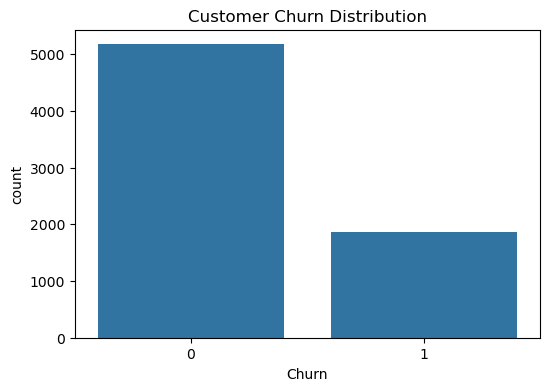

In [11]:
# 1: Churn Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)
plt.title("Customer Churn Distribution")
plt.show()

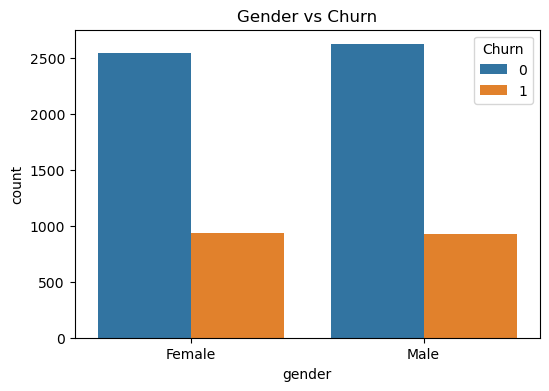

In [12]:
#  2: Churn by Gender
plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Churn")

plt.show()

In [13]:
# Age Group
df["AgeGroup"] = np.where(
    df["SeniorCitizen"]==1,
    "Senior",
    "Adult"
)

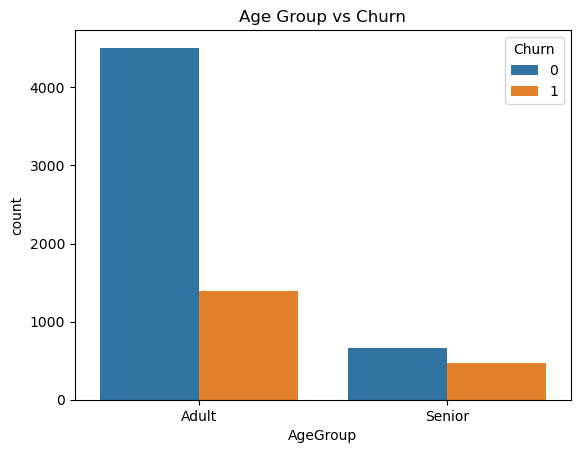

In [14]:
# 3: Age Group vs Churn
sns.countplot(
    x="AgeGroup",
    hue="Churn",
    data=df
)

plt.title("Age Group vs Churn")
plt.show()

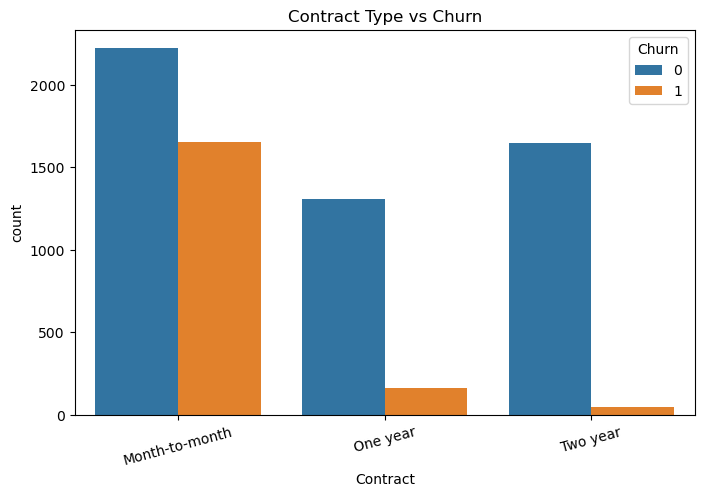

In [15]:
# 4: Contract vs Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

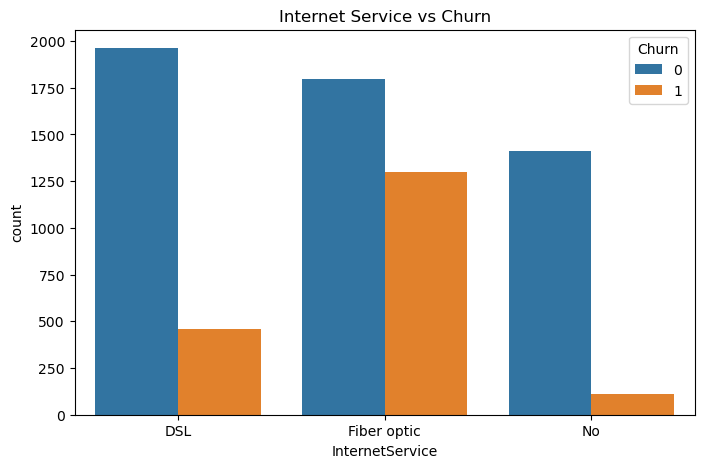

In [16]:
# 5: Internet Service vs Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

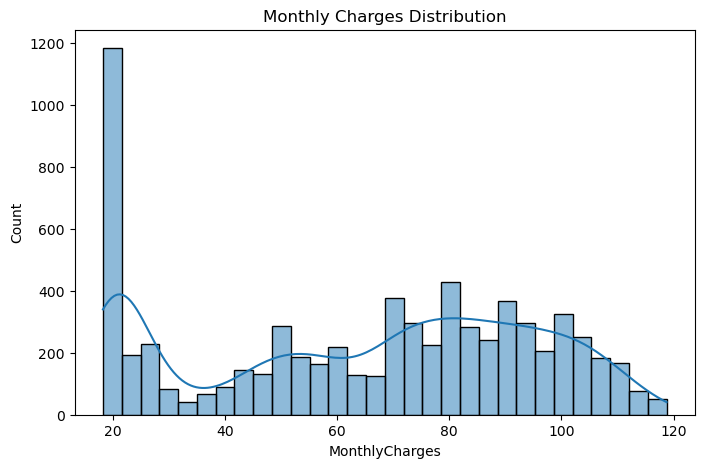

In [17]:
# 6: Monthly Charges Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

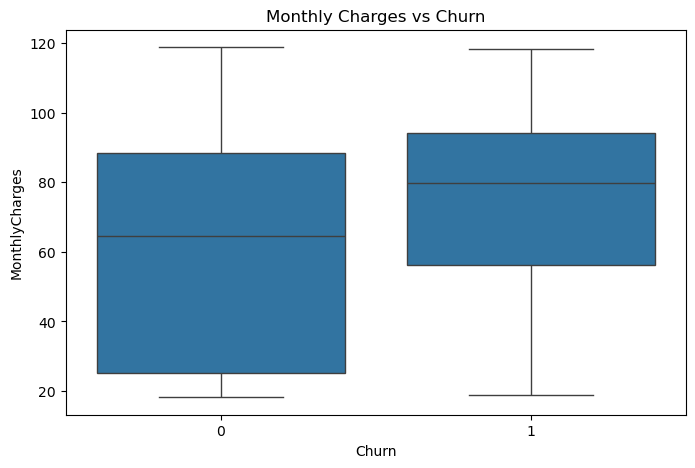

In [18]:
# 7: Monthly Charges vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

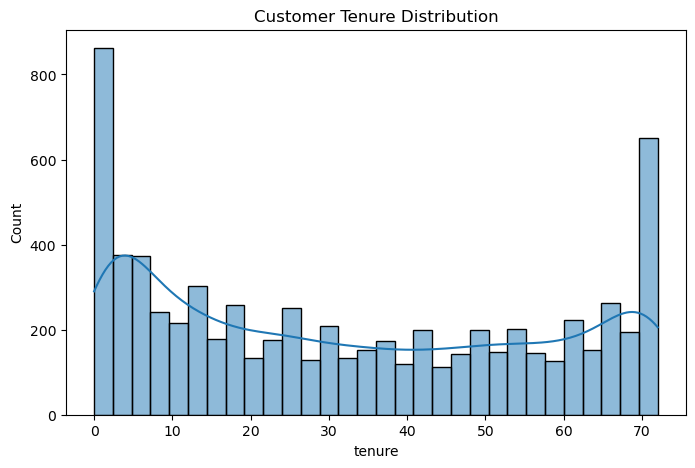

In [19]:
# 8: Tenure Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

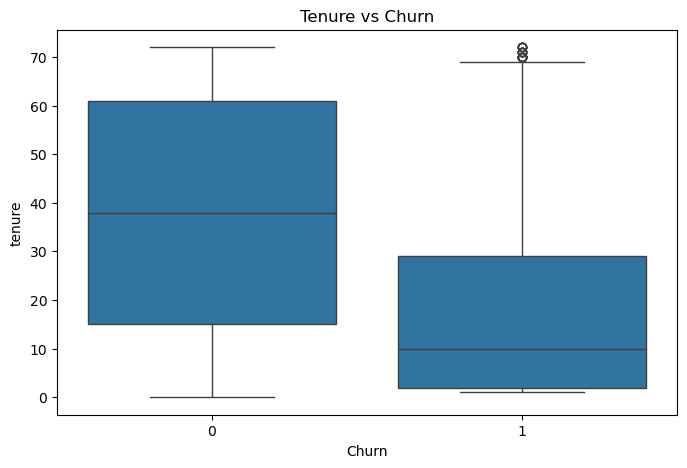

In [20]:
# 9: Tenure vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

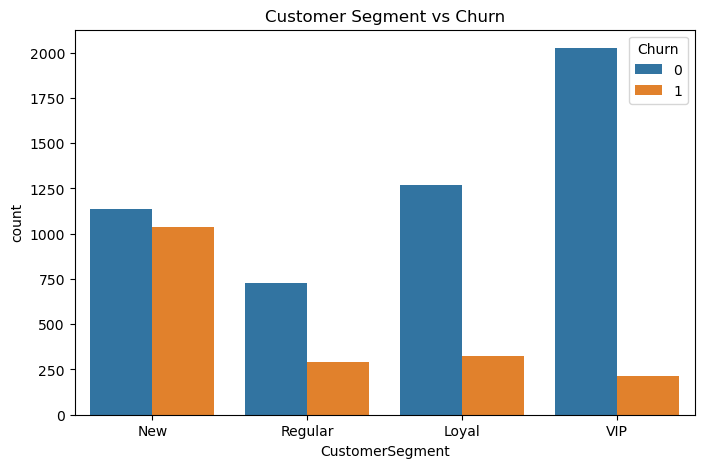

In [22]:
# 10: Customer Segmentation
plt.figure(figsize=(8,5))

sns.countplot(
    x="CustomerSegment",
    hue="Churn",
    data=df
)

plt.title("Customer Segment vs Churn")

plt.show()

In [23]:
df_ml = df.drop("customerID", axis=1)

df_encoded = pd.get_dummies(df_ml, drop_first=True)

In [24]:
df_encoded.shape

(7043, 32)

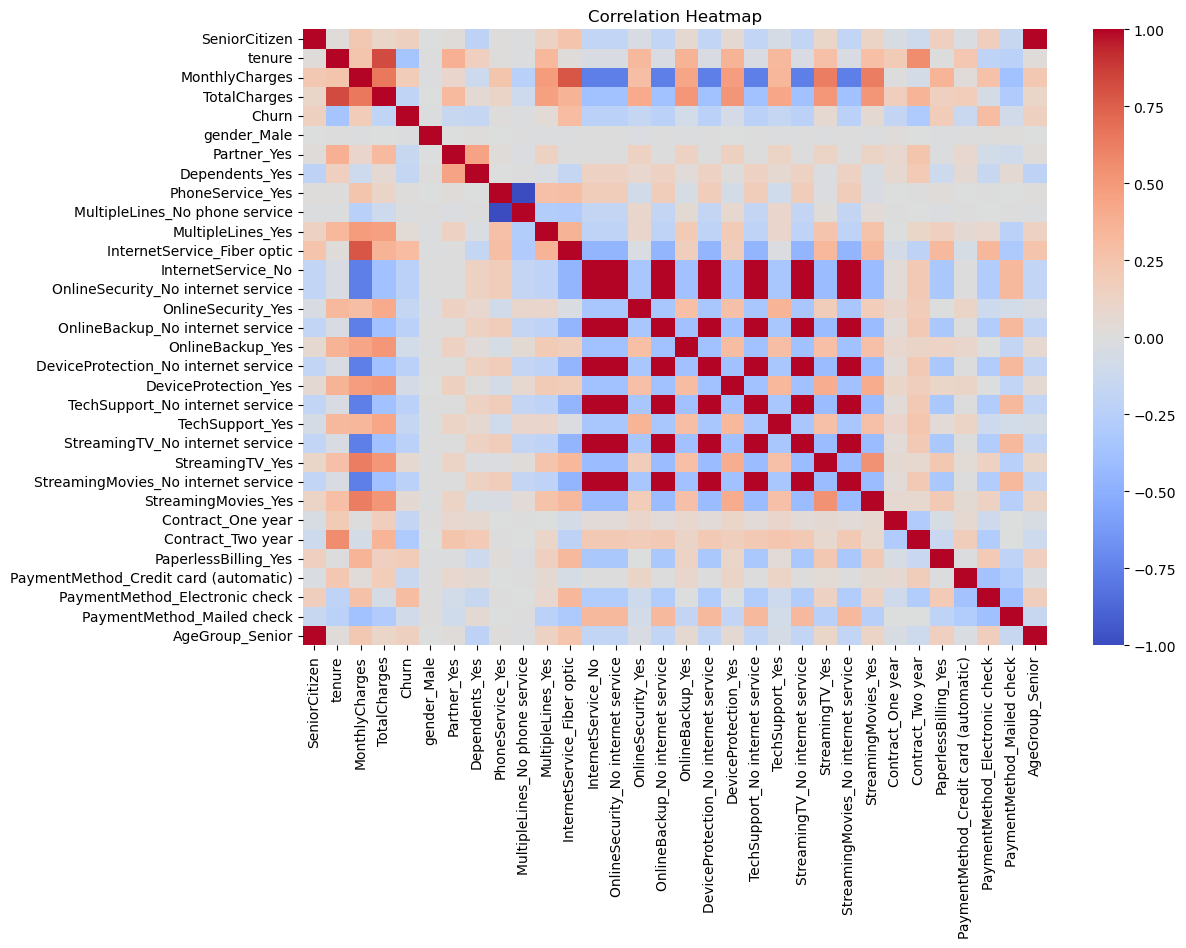

In [26]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

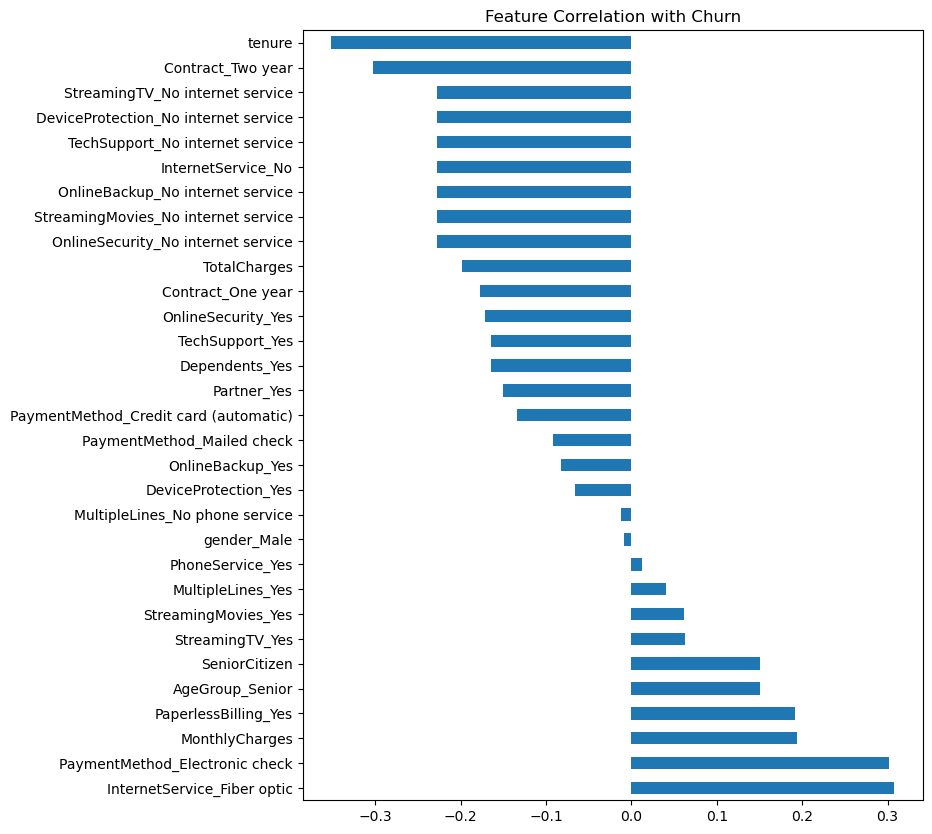

In [28]:
# only correlations with Churn:

corr = df_encoded.corr()['Churn'].sort_values(ascending=False)

plt.figure(figsize=(8,10))

corr.drop('Churn').plot(kind='barh')

plt.title("Feature Correlation with Churn")

plt.show()

# Business Insights & Recommendations

## 1. Overall Churn Rate
- The telecom company has a churn rate of approximately 26.5%.
- Nearly 1 in 4 customers discontinue services.

## 2. Contract Type is the Strongest Churn Driver
- Month-to-Month customers show the highest churn.
- Long-term contract customers are more loyal.

**Recommendation:** Promote long-term contracts through discounts and incentives.

## 3. Tenure Strongly Impacts Retention
- New customers churn more frequently.
- Long-tenure customers are highly loyal.

**Recommendation:** Improve onboarding and customer engagement during the first year.

## 4. Monthly Charges Influence Churn
- Customers with higher monthly charges are more likely to leave.

**Recommendation:** Introduce loyalty discounts and personalized plans.

## 5. Internet Service Analysis
- Fiber Optic customers exhibit higher churn.

**Recommendation:** Review Fiber pricing and service quality.

## 6. Senior Citizen Analysis
- Senior citizens show higher churn behavior.

**Recommendation:** Provide dedicated support and simplified plans.

## 7. Payment Method Impact
- Electronic Check users show elevated churn rates.

**Recommendation:** Encourage automatic payment methods.

## 8. Customer Segmentation Findings
- New Customers are the most vulnerable segment.
- Loyal and VIP Customers have the lowest churn rates.

## Executive Summary
Customer churn is primarily driven by Month-to-Month contracts, low tenure, and higher monthly charges. Retention strategies focused on onboarding, loyalty programs, and long-term contracts can significantly reduce churn.